# GaugePredict Data Downloader
Written by: Caitlin R. R. Turner (September 2025)
This notebook provides a workflow for downloading discharge data from USGS gauges.  
It is designed to support building predictor datasets for hydrologic modeling by:

- Selecting a **target gauge** where discharge will be predicted.  
- Identifying and downloading relevant **predictor sites** across Hydrologic Unit Code (HUC) zones.  
- Saving outputs, including site-level time series and a metadata index, for further analysis.  

The resulting dataset can then be used in GaugePredict workflows to model discharge at the target site using information from the selected HUC zones.

#### Download Packages

In [2]:
import os
import sys
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import cmocean
import contextily as ctx
from dataretrieval import nwis

from GaugePredict.downloader import GaugebyHUC
from GaugePredict.plotting import plot_hucs, plot_statistics

warnings.filterwarnings("ignore")


## Create File Directories 

In [3]:
nb_directory = Path.cwd()
project_root = nb_directory.parent
examples_dir = project_root / "Examples"

## Upload Shapefiles
Download the shapefiles for the basins you are interested in. Basin boundary shapefiles can be downloaded from the USGS National Hydrography dataset:  
[USGS National Hydrography Products](https://www.usgs.gov/national-hydrography/access-national-hydrography-products)

For this example, we will load all Hydrologic Unit Code (HUC) zones covering the Continental United States (CONUS) and Alaska.

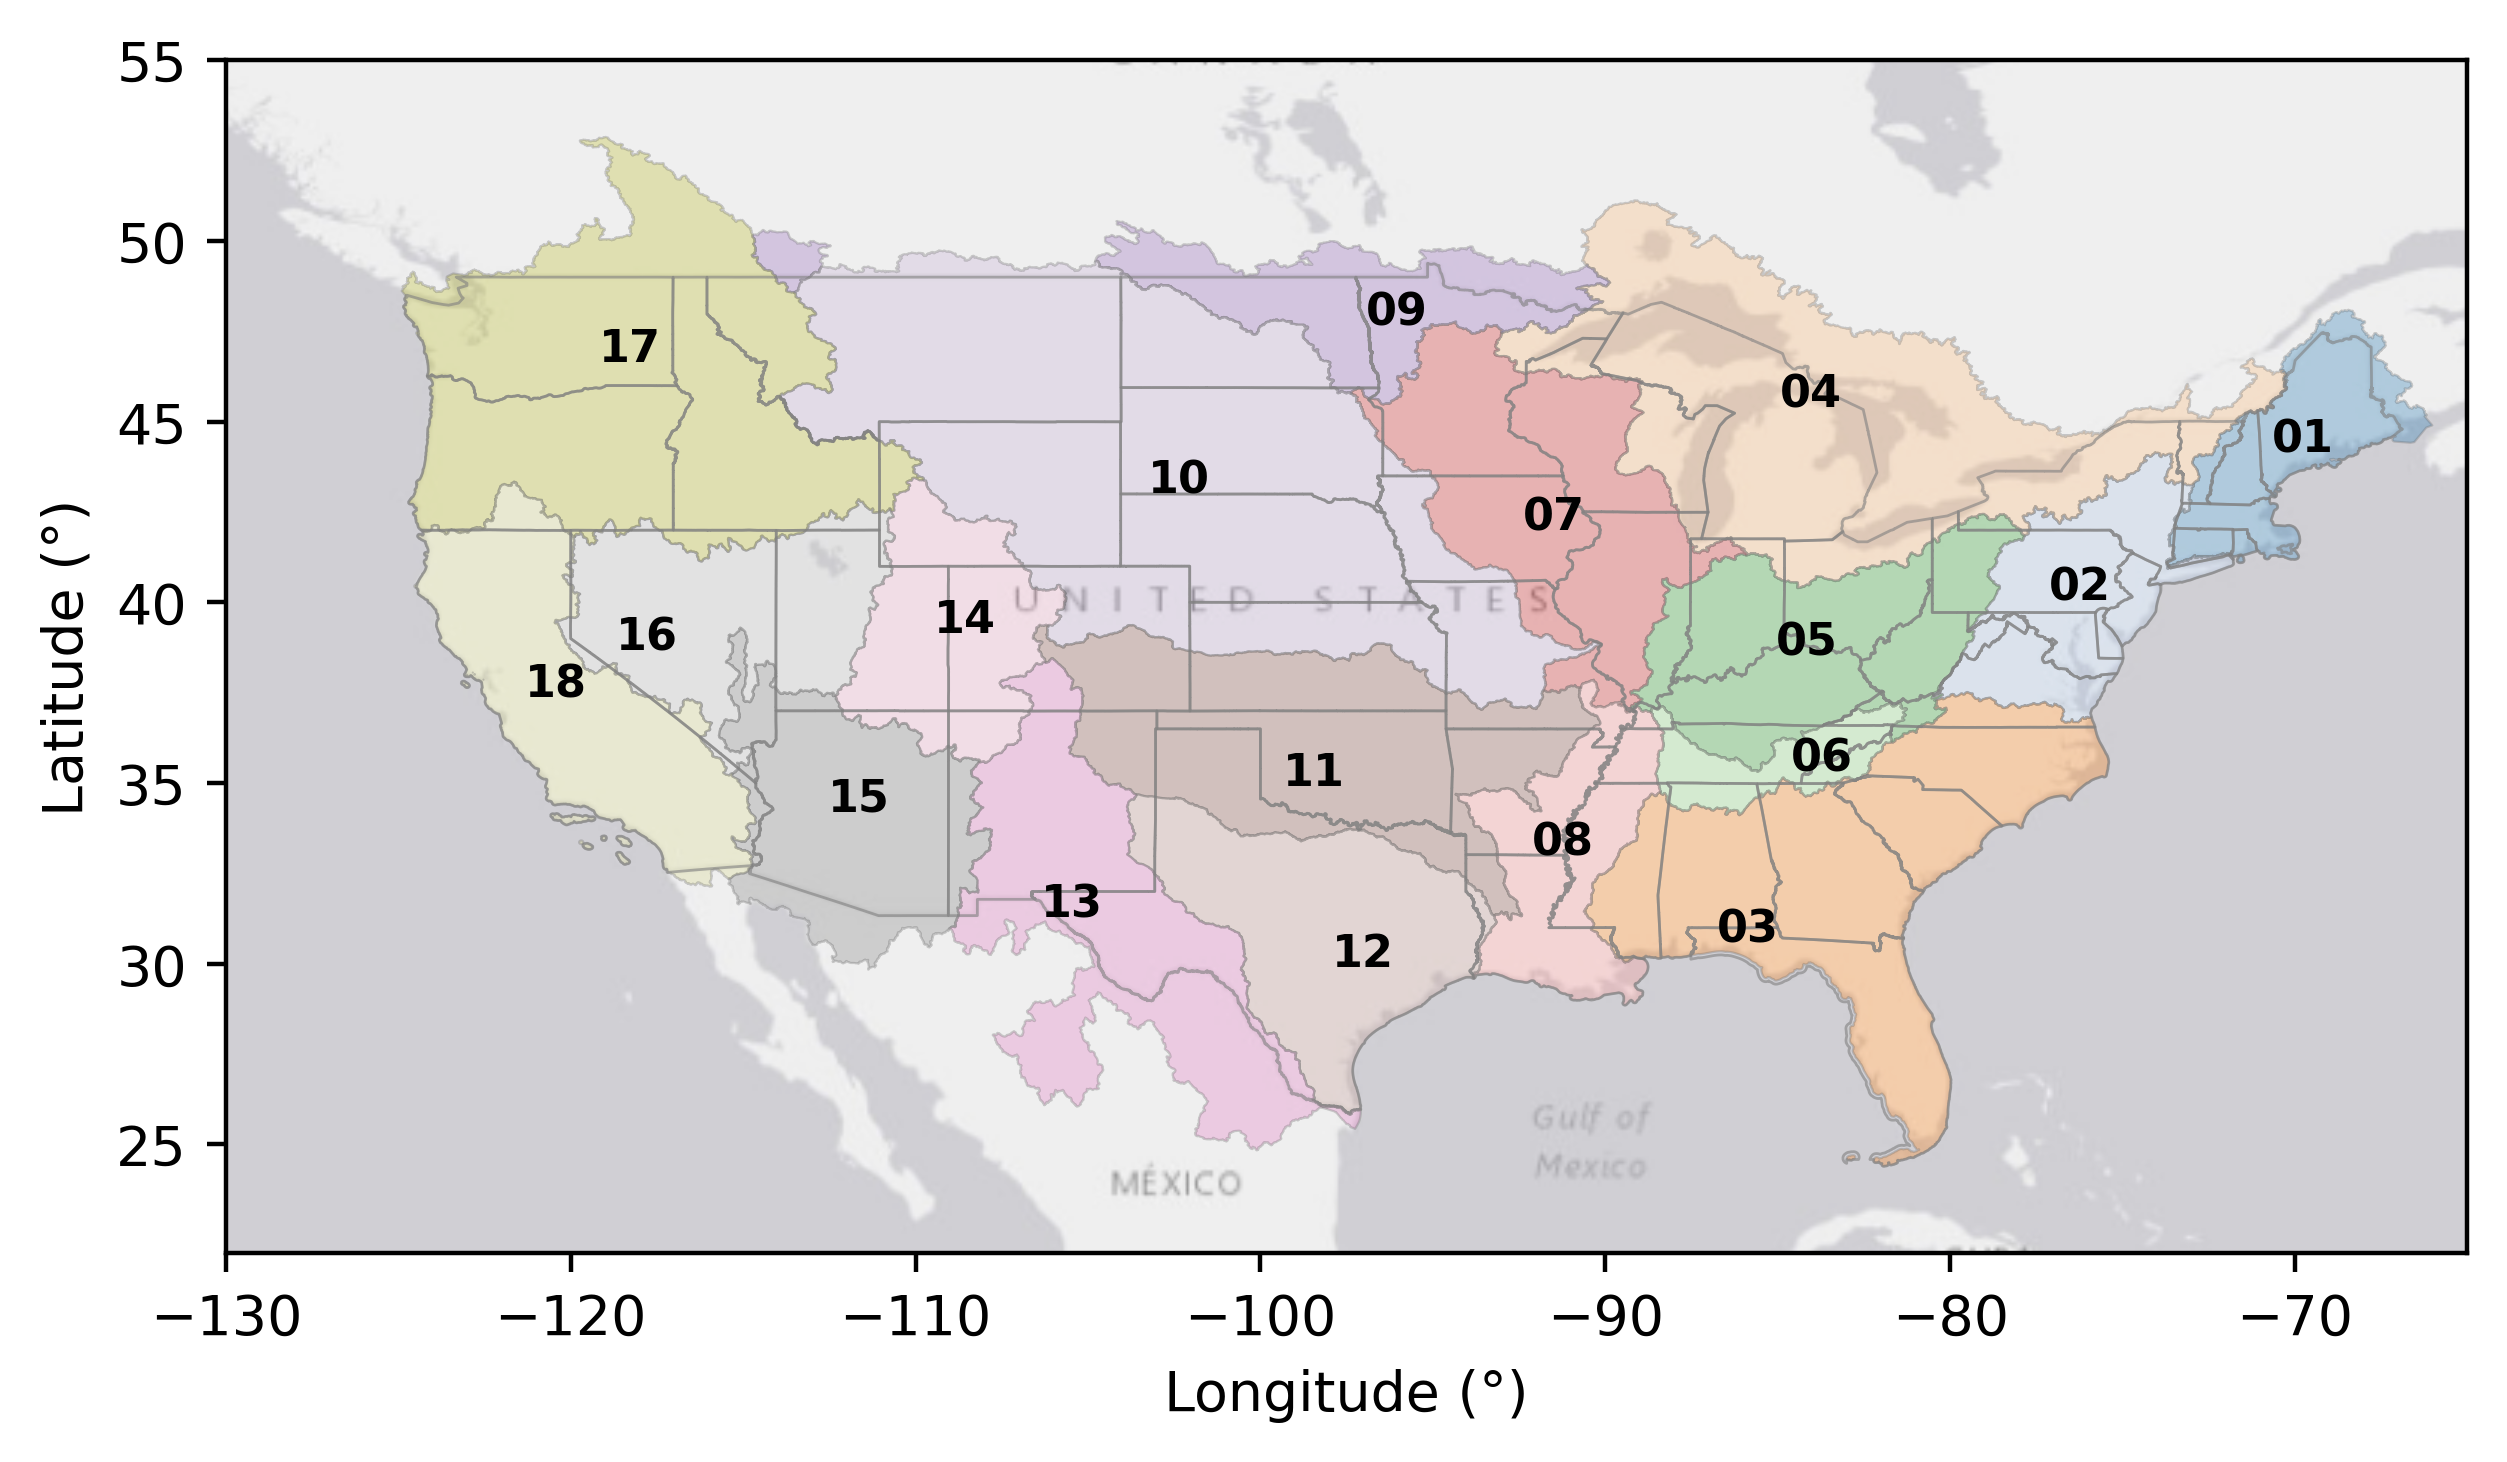

In [4]:
fig, ax = plot_hucs(
    base_dir="shapefiles/HUC_Zones",
    states_fp="shapefiles/US_STATES/tl_2023_us_state.shp",
    include_ak=False,
    basemap=True)


### Determine HUC Zones

For this step, we focus on the Hydrologic Unit Code (HUC) zones that fall within the Mississippi River Basin (MSRB).  

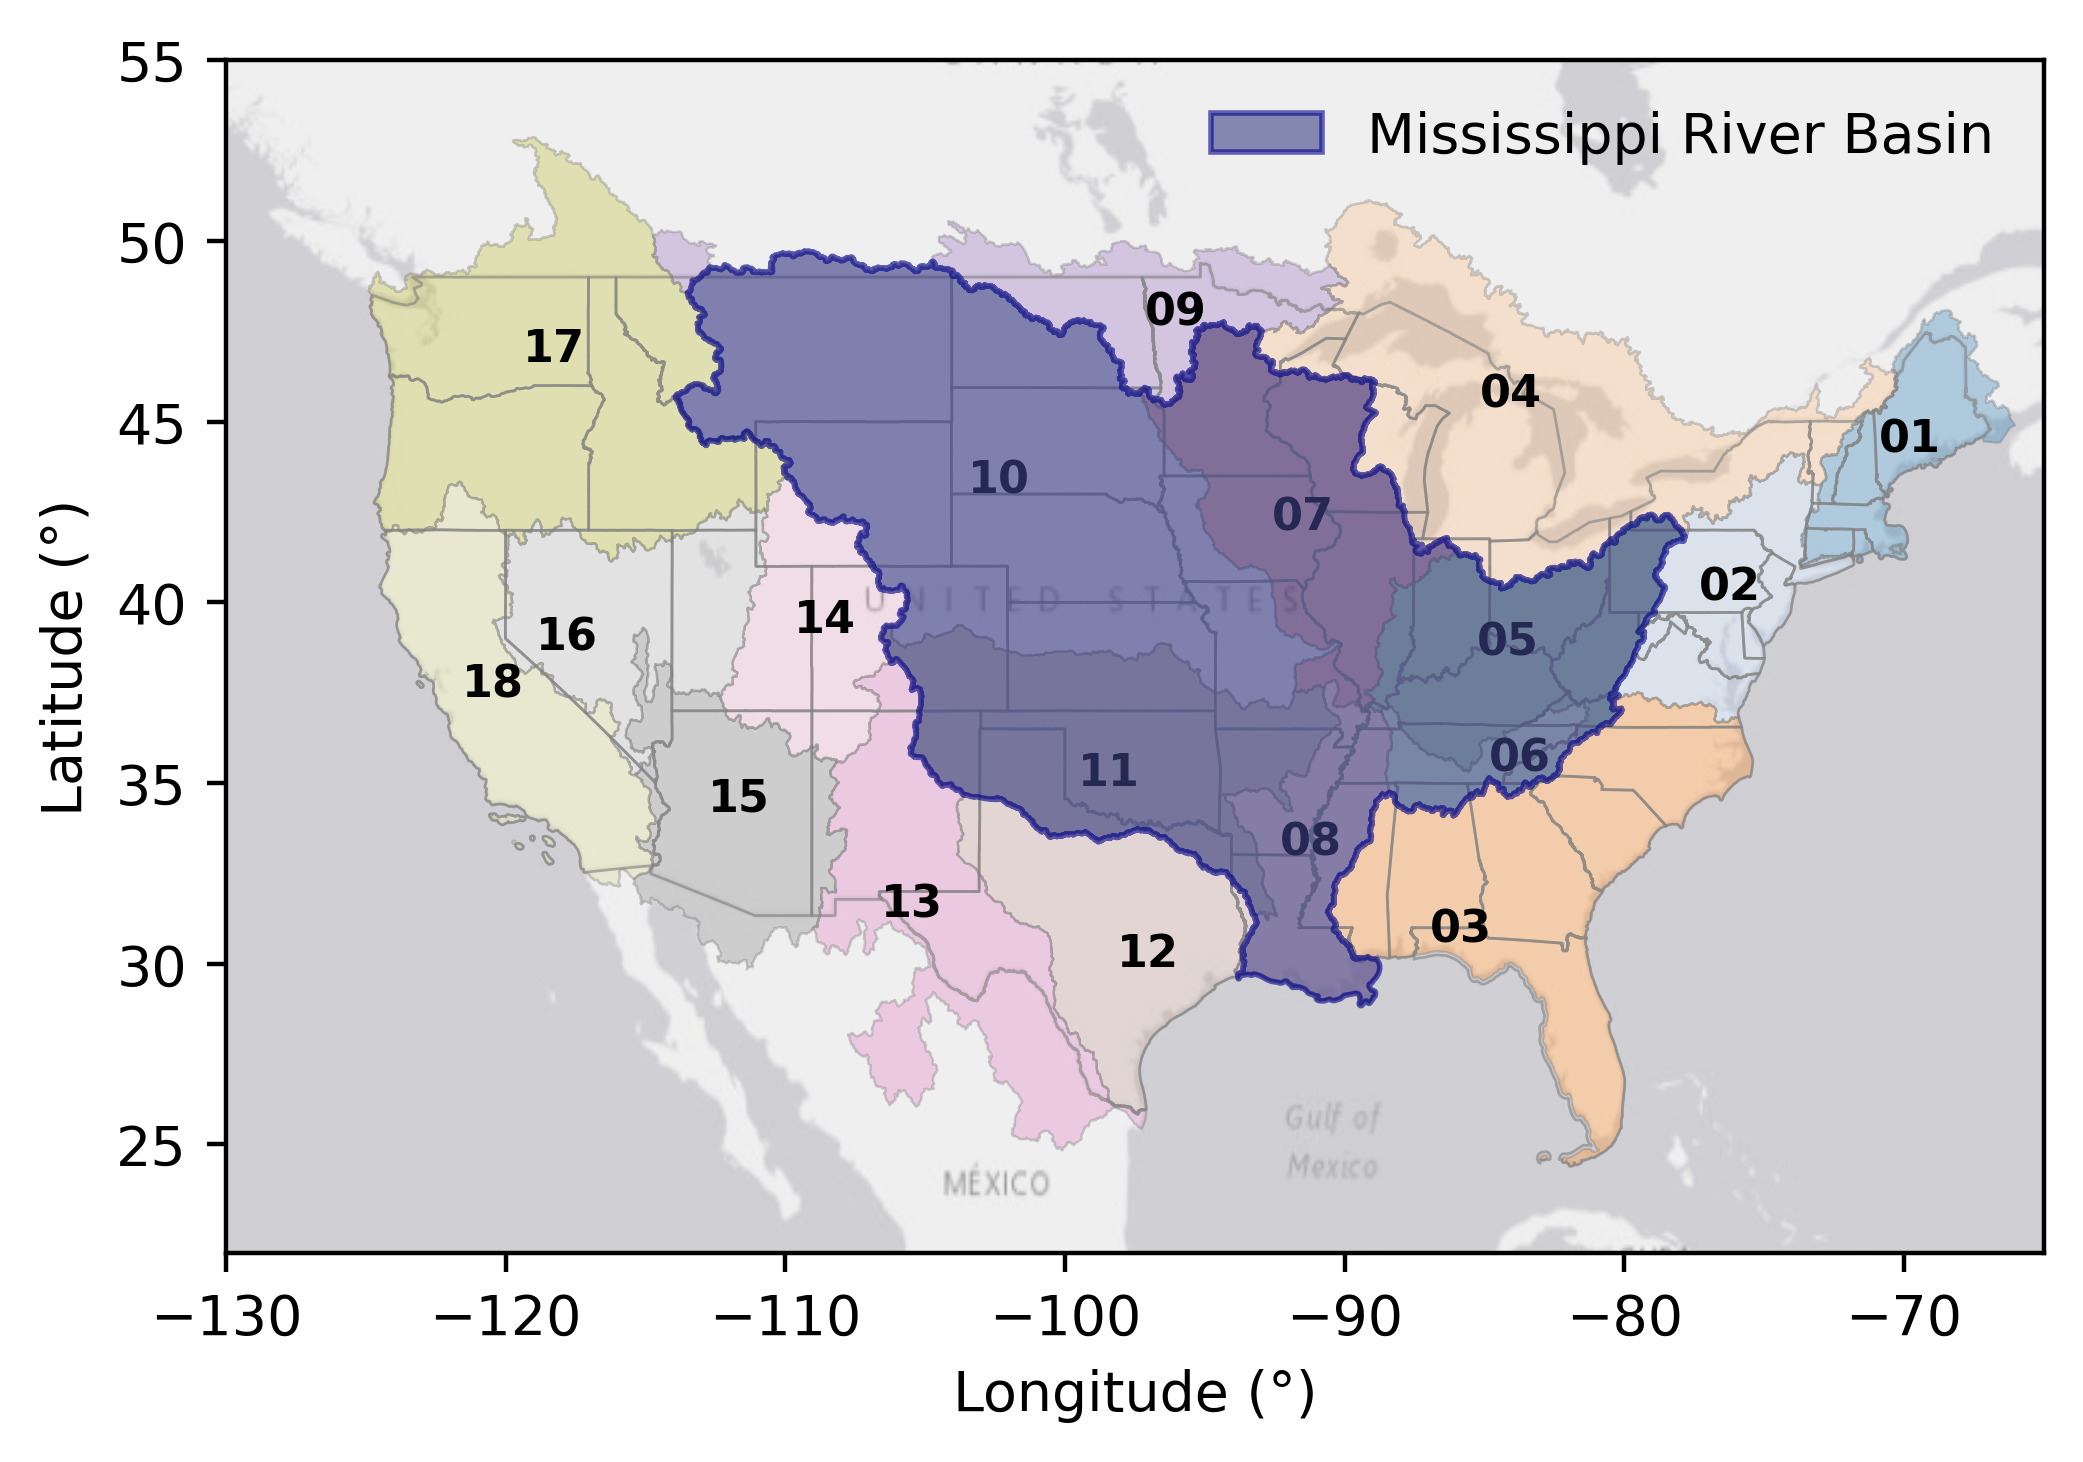

In [5]:
# your plotting
fig, ax = plot_hucs(
    base_dir="shapefiles/HUC_Zones",
    states_fp="shapefiles/US_STATES/tl_2023_us_state.shp",
    include_ak=False,  
    basemap=True)

target_epsg = 4326  # This changes the epsg to the same datum

basin = gpd.read_file("shapefiles/MSRB/Miss_RiverBasin.shp")
basin = basin.to_crs(target_epsg)

basin.plot(ax=ax,
           facecolor=cmocean.cm.ice(0.3),
           edgecolor="darkblue",
           alpha=0.6,
           zorder=4)

legend = ax.legend(
    handles=[mpatches.Patch(facecolor=cmocean.cm.ice(0.3),
                            edgecolor="darkblue",
                            alpha=0.6,
                            label="Mississippi River Basin")],
                            frameon=False, 
                            fontsize=10)


We can see that the HUC zones 05, 06, 07, 08, 10, and 11 fall within the Mississippi River Basin (MSRB).  We will also include HUC zone 09 because of its proximity to the basin. Discharge in the Mississippi River is strongly influenced by snowmelt, so including this adjacent zone helps capture upstream contributions.

In [6]:
huc_codes = ["05", "06", "07", "08", "09", "10", "11"]

## Downloading Discharge at a Target Site

We begin by selecting a target gauge. For this example, we focus on **Baton Rouge**.

Next, we download and inspect the discharge data for this site.  
To do this, we set the **start** and **end dates** based on our range of interest and the range of data available for the target site.

We can also specify the output units.  
The available options are:

- `metric`
- `customary`

Finally, we download the target site data for use in our analysis.
Lets download the target site data

In [8]:
parameter = "discharge"
parameter_code = "00060"
target_site = "07374000"
start_date, end_date = "2005-01-02", "2024-12-31"

df = nwis.get_dv(sites=target_site, parameterCd=parameter_code,
                 start=start_date, end=end_date)[0]

target = df["00060_Mean"] * 0.0283168466

full_index = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")

target = (target.reindex(full_index)
                .interpolate(limit_direction="both")
                .ffill().bfill())


Lets do some stats for the Target Site

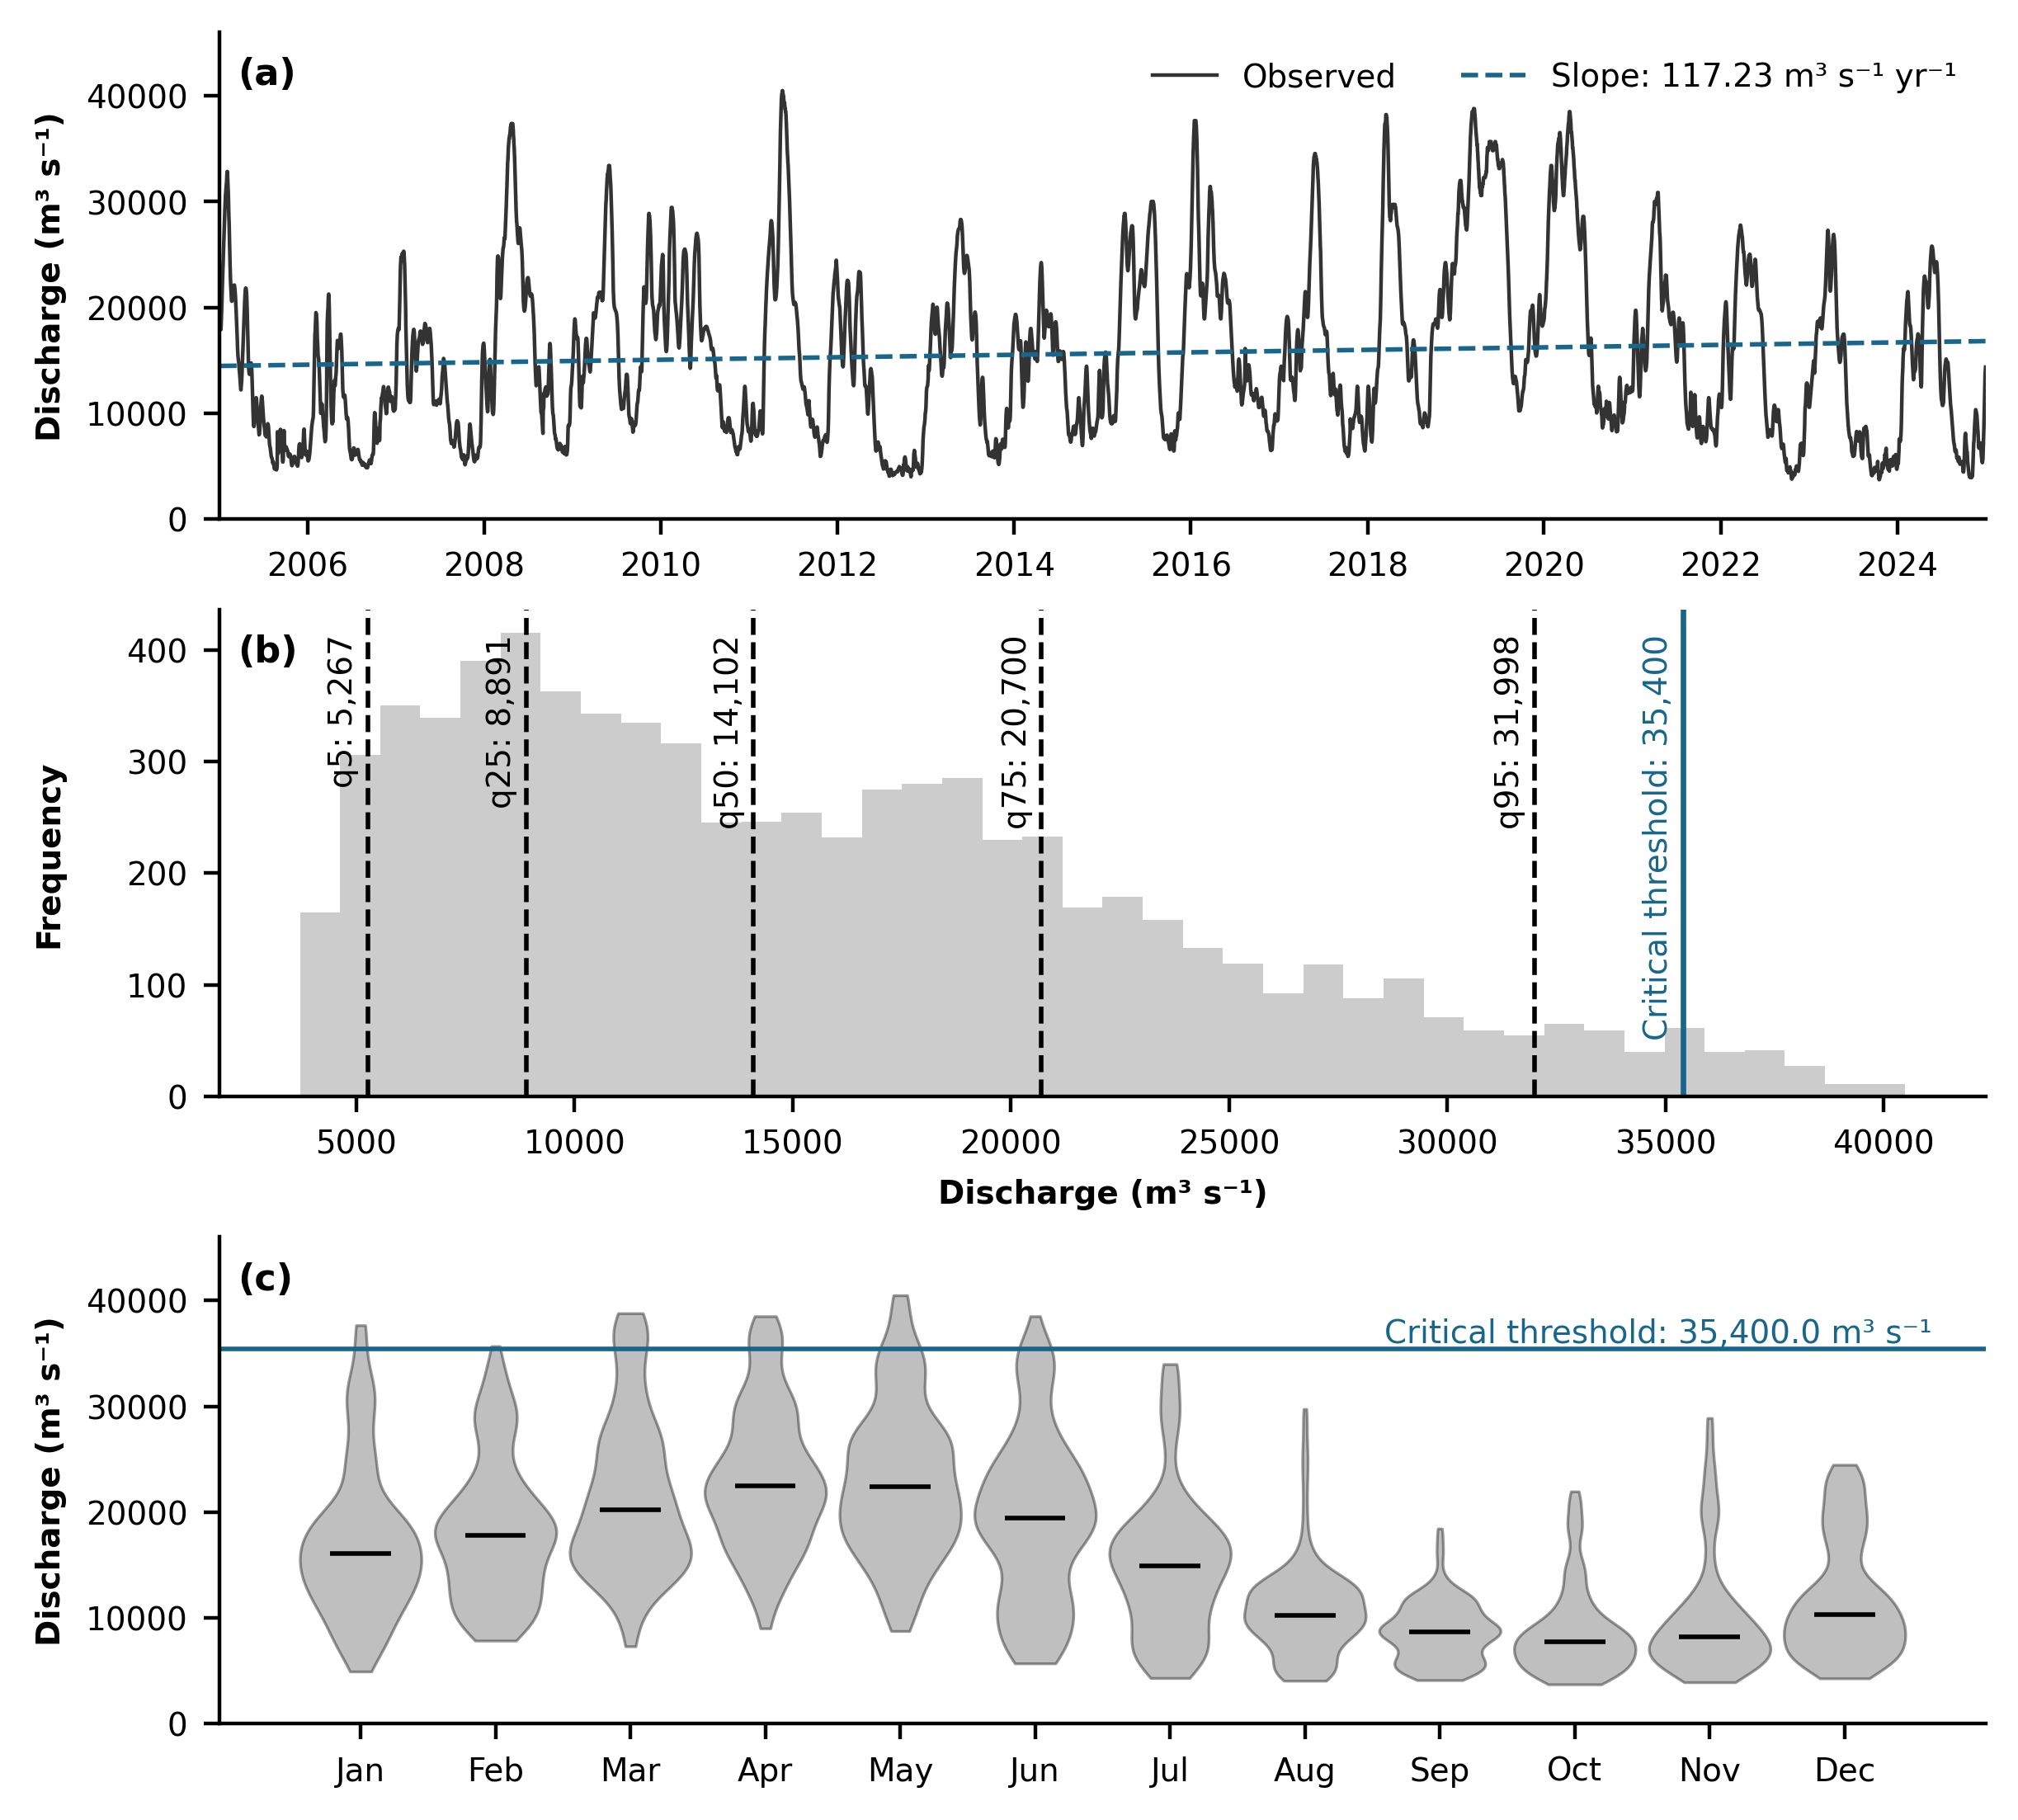

In [9]:
fig, axes = plot_statistics(target, critical_threshold=35400.0, ylim=(0, 46000))

## Download Predictor Sites by HUC

First, set the file path where predictor site data will be downloaded and stored.  
If data has already been collected, this path can also be used to upload and access existing files.  

We also define where to save the outputs. The time-series data for each site will be written to `data_dir/`, and a site-metadata index will be saved to `json_path`.


In [10]:
data_dir = Path(f"cached_data_{parameter}")
json_path = data_dir / f"site_dict_{parameter}.json"

We will build a predictor dataset from USGS gauges within the selected HUC zones. The goal is high coverage, so we filter sites using a `percent_threshold`. Here we set `percent_threshold = 95`, which keeps only sites whose daily record is at least 95% complete between `start_date` and `end_date`.

**Inputs**
- `start_date`, `end_date`: analysis window used both for data searching and completeness check.  
- `huc_codes`: list of HUC identifiers to search (e.g., `["07", "08"]`).  
- `parameter_code`: USGS parameter code (discharge is `00060`).  
- `percent_threshold`: minimum % of non-missing daily values per site in the window.  
- `siteType` (optional): USGS site type filter; use `'ST'` for streams, or set to `None`/omit to include all types.  
- `to_units`: unit system for output (`"metric"` or `"customary"`). Conversion is applied after download.

**Process**
1. Search sites in each HUC that report `parameter_code`.  
2. For each site, pull daily values over `[start_date, end_date]`.  
3. Check completeness; sites have data within the `percent_threshold`.  
4. Write daily series to `data_dir/` and a JSON site index to `json_path` with metadata (site number, name, HUC, period, completeness).  
5. Return a `summary` with counts.

**Outputs**
- Time-series files for each retained site in `data_dir/`.  
- `json_path`: dictionary of retained sites and their metadata.  
- `summary`: totals (sites found/kept), and pointers to outputs.

We will use these predictors to model discharge at the target site using the selected HUC zones. If you need other constituents, consult the USGS parameter catalog (e.g., discharge `00060`).

> Note: downloading from many sites can be slow because the code queries NWIS for each site. Data should only need to be downloaded the first time. A copy of this dataset can be found on HydroShare.

**Uncomment this section to download data from USGS**
(Downloading data may take quite a bit of time)

In [ ]:
percent_threshold = 95
to_units = "metric"           # or "customary"
parameter_code = "00060"      # USGS discharge (daily mean) parameter code

# Optional: restrict to streams only ('ST'); set to None or omit to include all site types
siteType = "ST"

summary = GaugebyHUC(
    start_date=start_date,
    end_date=end_date,
    huc_codes=huc_codes,
    parameter_code=parameter_code,
    percent_threshold=percent_threshold,
    data_dir=data_dir,
    json_path=json_path,
    siteType=siteType)

If you have any questions or need help with implementation to your model, please do not hesitate to contact Caitlin R. R. Turner at cturn65@lsu.edu 


#### **Acknowledgments:**
Research reported in this publication was supported by the US Department of Defense/Army Engineer Research and Development Center (ERDC) under Contract No. W912HZ2220005, the Gulf Research Program of the National Academies of Sciences, Engineering, and Medicine under award number SCON-10000883, and the NSF through Open Earthscape (Collaborative Research: Frameworks: OpenEarthscape - Transformative Cyberinfrastructure for Modeling and Simulation in the Earth-Surface Science Communities) award No. 2104102.